<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Tree_of_Lithography_Technologies_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using Python 3.13.15 environment at: /usr
Checked 2 packages in 90ms


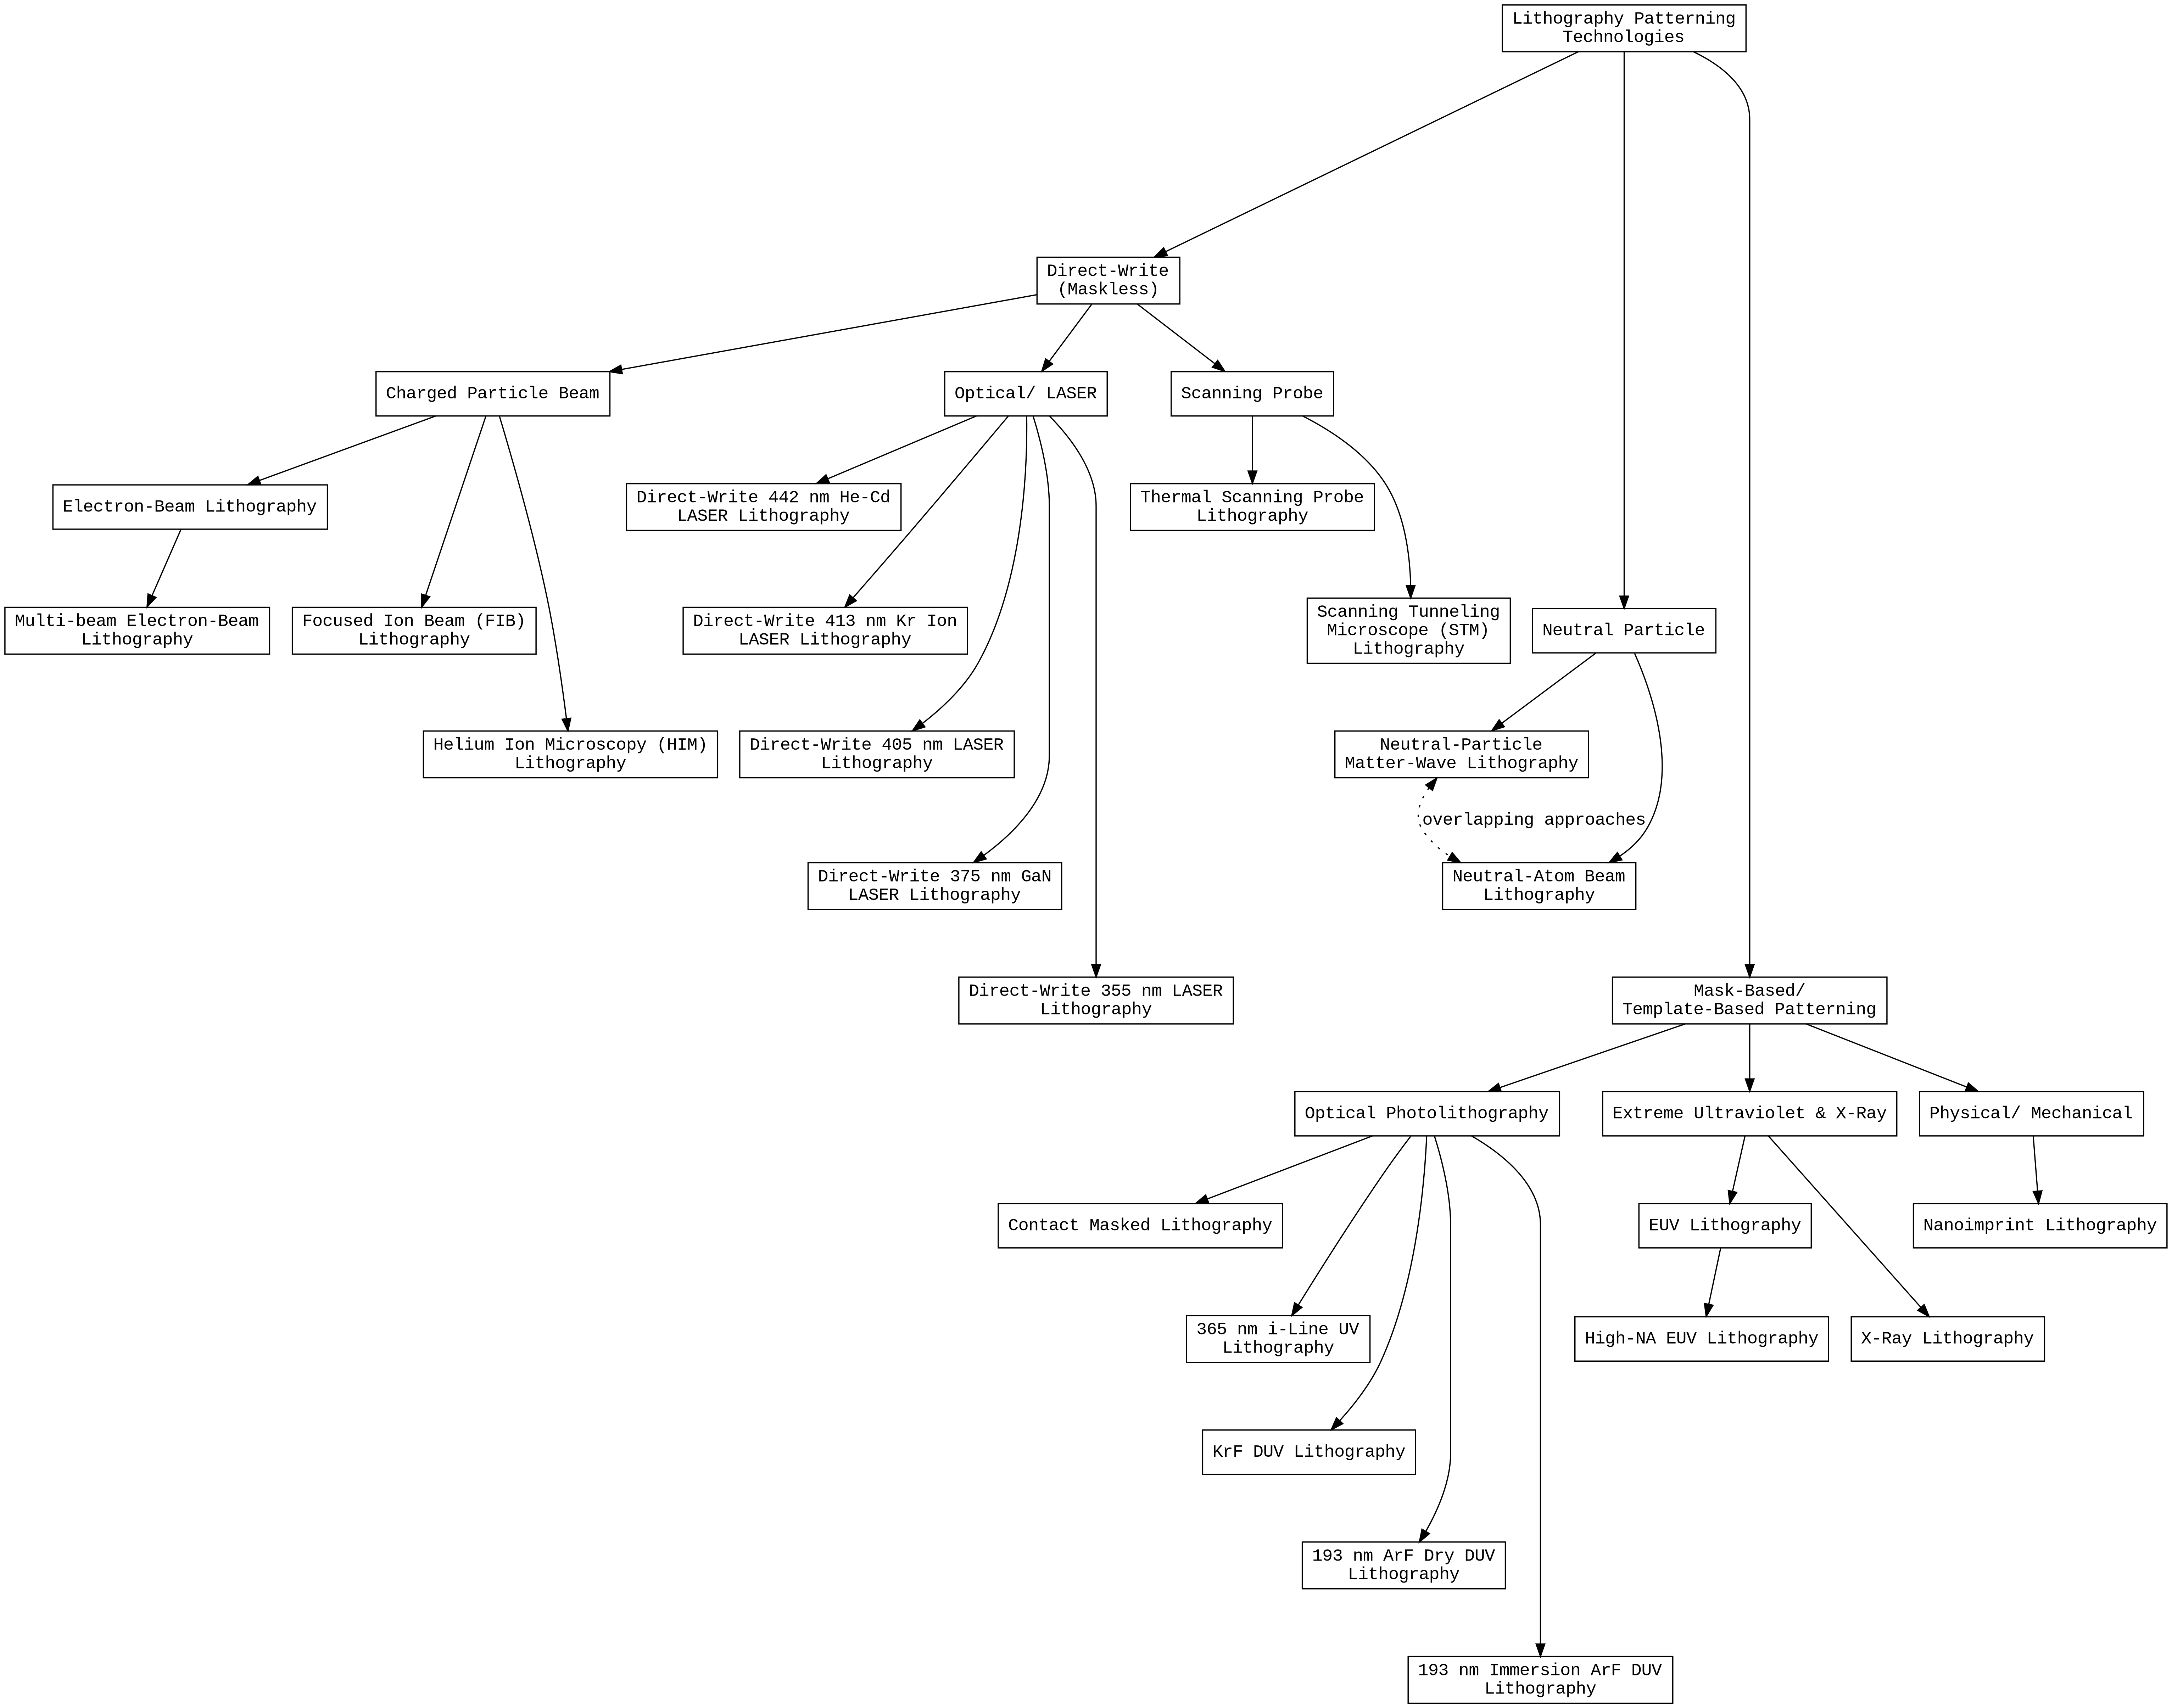

In [14]:
!uv pip install graphviz ipython

"""This script constructs a directed lithography classification graph and renders it in memory.

The graph avoids orthogonal edges and maintains an absolute monochrome aesthetic. Control
parameters defined at the top level dictate the precise font, resolution, and vertical spacing
characteristics. The script applies a hard character limit to each graphical node, cascades
primary branches, connects Neutral Particle directly to the root node, links Matter-Wave and
Neutral-Atom Beam Lithography with a labeled dotted edge, appends Scanning Tunneling Microscope
(STM) Lithography under the Scanning Probe branch, and places both Multi-beam Electron-Beam
Lithography and High-NA EUV Lithography directly underneath their respective parent nodes
without relying on HTML wrappers.
"""

import graphviz
from IPython.display import display
from IPython.display import Image

# Control Knobs
GRAPH_DPI = "250"
NODE_FONT = "DejaVu Sans"
NODE_FONT_WEIGHT = "normal"
EDGE_ROUTING = "spline"
NODE_SHAPE = "box"
BACKGROUND_COLOR = "white"
FOREGROUND_COLOR = "black"
RANK_DIRECTION = "TB"
MAX_CHARACTERS_PER_LINE = 27
RANK_SEPARATION = "0.75"
BRANCH_STAGGER_STEP = 3
SUB_NODE_MINLEN = "1"
DOTTED_EDGE_STYLE = "dotted"
OVERLAP_EDGE_DIR = "both"
OVERLAP_LABEL = "overlapping approaches"
STM_LITHOGRAPHY_LABEL = "Scanning Tunneling Microscope (STM) Lithography"


def wrap_text(text: str, max_width: int = MAX_CHARACTERS_PER_LINE) -> str:
  """Wraps text to a specified maximum width, hyphenating oversized strings.

  Args:
      text: The original string input.
      max_width: The maximum allowable characters per line.

  Returns:
      A formatted string featuring newline characters at proper intervals.
  """
  lines = []
  for paragraph in text.split("\n"):
    current_line = ""
    words = paragraph.split()
    for word in words:
      while len(word) > max_width:
        if current_line:
          lines.append(current_line)
          current_line = ""
        chunk = word[: max_width - 1] + "-"
        lines.append(chunk)
        word = word[max_width - 1 :]

      if current_line:
        if len(current_line) + 1 + len(word) <= max_width:
          current_line += " " + word
        else:
          lines.append(current_line)
          current_line = word
      else:
        current_line = word
    if current_line:
      lines.append(current_line)
  return "\n".join(lines)


def build_lithography_tree() -> graphviz.Digraph:
  """Constructs the directed Graphviz object outlining lithography classifications.

  Returns:
      A configured graphviz.Digraph instance representing the technology tree.
  """
  tree = graphviz.Digraph(format="png")

  tree.attr(
      dpi=GRAPH_DPI,
      splines=EDGE_ROUTING,
      bgcolor=BACKGROUND_COLOR,
      rankdir=RANK_DIRECTION,
      ranksep=RANK_SEPARATION,
  )
  tree.attr(
      "node",
      shape=NODE_SHAPE,
      style="solid",
      color=FOREGROUND_COLOR,
      fontcolor=FOREGROUND_COLOR,
      fontname=NODE_FONT,
  )
  tree.attr(
      "edge",
      color=FOREGROUND_COLOR,
      fontcolor=FOREGROUND_COLOR,
      fontname=NODE_FONT,
      arrowhead="normal",
  )

  tree.node("Root", wrap_text("Lithography Patterning Technologies"))

  def add_staggered_leaves(parent_id: str, leaves: list[str]) -> None:
    """Attaches leaf nodes to a parent node and staggers them vertically."""
    for idx, leaf_text in enumerate(leaves):
      leaf_id = f"{parent_id}_L_{idx}"
      tree.node(leaf_id, wrap_text(leaf_text))
      tree.edge(parent_id, leaf_id, minlen=str(idx + 1))

  # Primary Branches Connected Directly to Root
  tree.node("Maskless", wrap_text("Direct-Write\n(Maskless)"))
  tree.edge("Root", "Maskless", minlen=str(1 * BRANCH_STAGGER_STEP))

  tree.node("NP_Branch", wrap_text("Neutral Particle"))
  tree.edge("Root", "NP_Branch", minlen=str(2 * BRANCH_STAGGER_STEP))

  tree.node("Masked", wrap_text("Mask-Based/\nTemplate-Based Patterning"))
  tree.edge("Root", "Masked", minlen=str(3 * BRANCH_STAGGER_STEP))

  # Maskless Sub-branches: Charged Particle Beam with Hierarchical Multi-beam EBL
  tree.node("ML_CP", wrap_text("Charged Particle Beam"))
  tree.edge("Maskless", "ML_CP")

  tree.node("ML_CP_EBL", wrap_text("Electron-Beam Lithography"))
  tree.edge("ML_CP", "ML_CP_EBL", minlen="1")

  tree.node("ML_CP_MultiEBL", wrap_text("Multi-beam Electron-Beam Lithography"))
  tree.edge("ML_CP_EBL", "ML_CP_MultiEBL", minlen=SUB_NODE_MINLEN)

  tree.node("ML_CP_FIB", wrap_text("Focused Ion Beam (FIB) Lithography"))
  tree.edge("ML_CP", "ML_CP_FIB", minlen="2")

  tree.node("ML_CP_HIM", wrap_text("Helium Ion Microscopy (HIM) Lithography"))
  tree.edge("ML_CP", "ML_CP_HIM", minlen="3")

  tree.node("ML_Opt", wrap_text("Optical/ LASER"))
  tree.edge("Maskless", "ML_Opt")
  add_staggered_leaves(
      "ML_Opt",
      [
          "Direct-Write 442 nm He-Cd LASER Lithography",
          "Direct-Write 413 nm Kr Ion LASER Lithography",
          "Direct-Write 405 nm LASER Lithography",
          "Direct-Write 375 nm GaN LASER Lithography",
          "Direct-Write 355 nm LASER Lithography",
      ],
  )

  tree.node("ML_Probe", wrap_text("Scanning Probe"))
  tree.edge("Maskless", "ML_Probe")
  add_staggered_leaves(
      "ML_Probe",
      [
          "Thermal Scanning Probe Lithography",
          STM_LITHOGRAPHY_LABEL,
      ],
  )

  # Neutral Particle Sub-branches with Dotted Overlap Connection
  tree.node("NP_MatterWave", wrap_text("Neutral-Particle Matter-Wave Lithography"))
  tree.edge("NP_Branch", "NP_MatterWave", minlen="1")

  tree.node("NP_NeutralAtom", wrap_text("Neutral-Atom Beam Lithography"))
  tree.edge("NP_Branch", "NP_NeutralAtom", minlen="2")

  tree.edge(
      "NP_MatterWave",
      "NP_NeutralAtom",
      style=DOTTED_EDGE_STYLE,
      dir=OVERLAP_EDGE_DIR,
      label=wrap_text(OVERLAP_LABEL),
  )

  # Mask-Based / Template-Based Sub-branches
  tree.node("M_Photo", wrap_text("Optical Photolithography"))
  tree.edge("Masked", "M_Photo")
  add_staggered_leaves(
      "M_Photo",
      [
          "Contact Masked Lithography",
          "365 nm i-Line UV Lithography",
          "KrF DUV Lithography",
          "193 nm ArF Dry DUV Lithography",
          "193 nm Immersion ArF DUV Lithography",
      ],
  )

  # Extreme Ultraviolet & X-Ray with Hierarchical High-NA Sub-node
  tree.node("M_Adv", wrap_text("Extreme Ultraviolet & X-Ray"))
  tree.edge("Masked", "M_Adv")

  tree.node("M_Adv_EUV", wrap_text("EUV Lithography"))
  tree.edge("M_Adv", "M_Adv_EUV", minlen="1")

  tree.node("M_Adv_HighNA_EUV", wrap_text("High-NA EUV Lithography"))
  tree.edge("M_Adv_EUV", "M_Adv_HighNA_EUV", minlen=SUB_NODE_MINLEN)

  tree.node("M_Adv_XRay", wrap_text("X-Ray Lithography"))
  tree.edge("M_Adv", "M_Adv_XRay", minlen="2")

  tree.node("M_Mech", wrap_text("Physical/ Mechanical"))
  tree.edge("Masked", "M_Mech")
  add_staggered_leaves("M_Mech", ["Nanoimprint Lithography"])

  return tree


def render_in_memory(tree: graphviz.Digraph) -> None:
  """Renders the Graphviz object directly in memory without HTML wrappers.

  Args:
      tree: The constructed graphviz.Digraph instance.
  """
  binary_png = tree.pipe(format="png")
  display(Image(data=binary_png))

if __name__ == "__main__":
  lithography_tree = build_lithography_tree()
  render_in_memory(lithography_tree)